# Comprendre le mapping sphérique (projection équirectangulaire)

Ce notebook démontre comment fonctionne mathématiquement le mappage d'une image sur une sphère.
Une image **équirectangulaire** (type panorama 360°) est une projection où :
- la largeur correspond à la longitude (θ ∈ [-π, π])
- la hauteur correspond à la latitude (φ ∈ [-π/2, π/2])

## Plan du notebook

1. **Coordonnées sphériques → cartésiennes** : conversion (θ, φ) → (x, y, z) sur la sphère unité x²+y²+z²=1
2. **UV image → angles sphériques** : transformation des coordonnées pixel (u, v) ∈ [0,1] en (θ, φ)
3. **Visualisation** : application de l'image comme texture sur la sphère en utilisant les UV existantes


In [194]:
# Bibliothèques pour le calcul numérique et la visualisation 3D
import numpy as np
import matplotlib.pyplot as plt

## 1️⃣ Conversion sphérique → cartésienne

Sur la **sphère unité** (rayon = 1), tout point vérifie x² + y² + z² = 1.

Paramétrisation par les angles :
- **θ (theta)** : longitude ∈ [-π, π], angle autour de l'axe vertical
- **φ (phi)** : latitude ∈ [-π/2, π/2], angle depuis le plan équatorial (pôle sud → pôle nord)

**Formules de conversion :**
```
x = cos(φ) × sin(θ)
y = sin(φ)           ← axe vertical (hauteur)
z = cos(φ) × cos(θ)
```

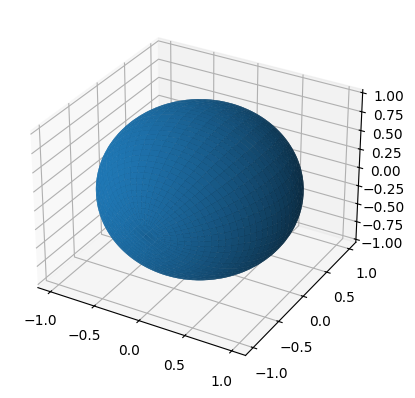

In [195]:
# Grilles d'angles : theta (longitude) et phi (latitude)
theta = np.linspace(-np.pi, np.pi, 200)      # 200 points de -π à π
phi = np.linspace(-np.pi/2, np.pi/2, 100)   # 100 points de -π/2 à π/2

# Création des grilles 2D pour chaque point de la surface
theta_grid, phi_grid = np.meshgrid(theta, phi)

# Conversion en coordonnées cartésiennes (sphère unité)
x = np.cos(phi_grid) * np.sin(theta_grid)
y = np.sin(phi_grid)
z = np.cos(phi_grid) * np.cos(theta_grid)

# Affichage de la sphère (sans texture)
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.plot_surface(x, y, z)
plt.show()

## 2️⃣ UV (espace image) → angles sphériques

Pour une image **équirectangulaire**, chaque pixel est repéré par :
- **u ∈ [0, 1]** : coordonnée horizontale (0 = bord gauche, 1 = bord droit)
- **v ∈ [0, 1]** : coordonnée verticale (0 = bas / pôle sud, 1 = haut / pôle nord)

**Formules de conversion UV → angles :**
```
θ = 2π·u - π         (u=0 → θ=-π, u=1 → θ=π)
φ = π·v - π/2        (v=0 → φ=-π/2, v=1 → φ=π/2)
```

Cela permet d'associer chaque pixel de l'image à un point unique sur la sphère.

### Chargement de l'image source

L'image doit être au format **équirectangulaire** (panorama 360°) pour que le mapping soit correct.
Les dimensions de l'image peuvent différer de la grille UV ; l'échantillonnage s'adapte automatiquement.

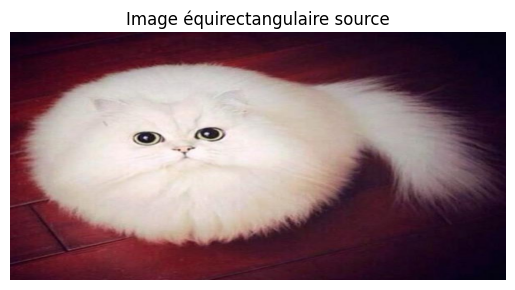

In [196]:
# Chargement de l'image équirectangulaire (format RGB pour la texture)
from PIL import Image

img_path = r"C:\Users\mvm\open3d_vision\data\test_tres_serieux.jpg"
image = Image.open(img_path).convert("RGB")
# Format équirectangulaire : rapport 2:1 (360° long. / 180° lat.) pour mapping correct
w_img, h_img = image.size
if abs(w_img / h_img - 2.0) > 0.01:
    h_new = max(h_img, w_img // 2)
    w_new = 2 * h_new
    image = image.resize((w_new, h_new), Image.LANCZOS)
plt.imshow(image)
plt.title("Image équirectangulaire source")
plt.axis("off")
plt.show()


### Création de la grille UV et conversion en angles

La grille (u_grid, v_grid) couvre l'espace [0,1]². Chaque point (u, v) est converti en (θ, φ) puis en (x, y, z) sur la sphère.

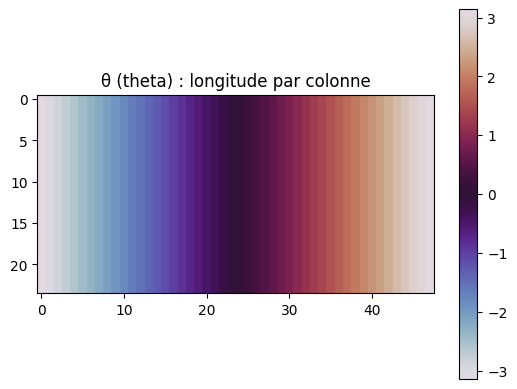

In [197]:
# Grilles UV : même résolution que la texture souhaitée
u = np.linspace(0, 1, 48)    # 48 colonnes (maillage réduit)
v = np.linspace(0, 1, 24)    # 24 lignes (maillage réduit)
u_grid, v_grid = np.meshgrid(u, v)


# Conversion UV → angles sphériques (formules équirectangulaires)
theta_uv = 2 * np.pi * u_grid - np.pi      # longitude
phi_uv = np.pi * v_grid - np.pi/2          # latitude

# Visualisation des angles theta (chaque colonne = une longitude)
plt.figure()
plt.imshow(theta_uv, cmap="twilight")
plt.title("θ (theta) : longitude par colonne")
plt.colorbar()
plt.show()

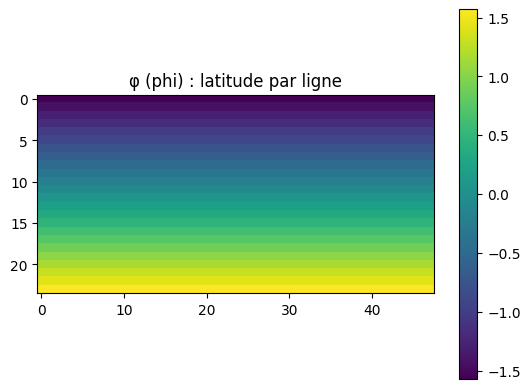

In [198]:
# Visualisation des angles phi (chaque ligne = une latitude)
plt.figure()
plt.imshow(phi_uv, cmap="viridis")
plt.title("φ (phi) : latitude par ligne")
plt.colorbar()
plt.show()

## 3️⃣ Application de la texture sur la sphère

On combine les étapes précédentes :
1. Les **UV** (u_grid, v_grid) définissent la grille de paramétrisation
2. Les **angles** (theta_uv, phi_uv) positionnent chaque point sur la sphère x²+y²+z²=1
3. Chaque point (u, v) de l'image est mappé sur le point correspondant de la sphère

Le paramètre `facecolors` de `plot_surface` applique les couleurs de l'image aux faces du maillage.

**Variables X et Y** : décalent la texture sur la sphère (valeurs dans [0, 1], wrapping). X = décalage horizontal, Y = décalage vertical.

### Visualisation des UV sur la sphère

Coloration par coordonnées UV : **rouge = u** (longitude), **vert = v** (latitude). Permet de vérifier le mapping et détecter les décalages.

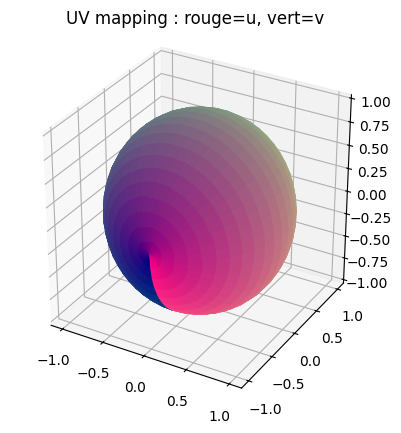

In [199]:
# Couleurs UV : R=u, G=v, B=0.5 (pour lisibilité)
uv_colors = np.ones((u_tex.shape[0] - 1, u_tex.shape[1] - 1, 4))
uv_colors[:, :, 0] = u_tex[:-1, :-1]   # rouge = u
uv_colors[:, :, 1] = v_tex[:-1, :-1]   # vert = v
uv_colors[:, :, 2] = 0.5              # bleu fixe

fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.plot_surface(x2, y2, z2, facecolors=uv_colors, rstride=1, cstride=1, shade=False)
ax.set_box_aspect([1, 1, 1])
plt.title('UV mapping : rouge=u, vert=v')
plt.show()

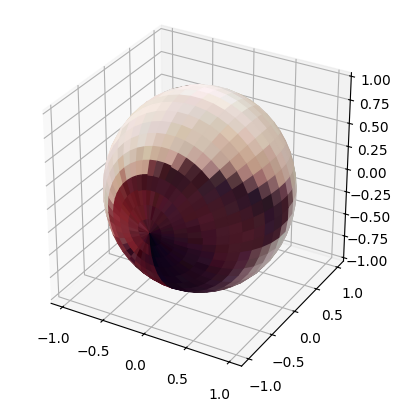

In [200]:
# --- Sphère unité x²+y²+z²=1 paramétrée par les UV existantes ---
x2 = np.cos(phi_uv) * np.sin(theta_uv)
y2 = np.sin(phi_uv)
z2 = np.cos(phi_uv) * np.cos(theta_uv)

# --- Décalage de la texture (X horizontal, Y vertical) ---
X, Y = 0.0, 0.0  # [0, 1] : X=0.5 = demi-tour horizontal
TX, TY = 1.0, 1.0  # scale UV (typo corrigée : était 1,1,)
# u : % 1.0 correct (longitude fermée) mais 1.0 % 1.0 = 0 → perte de u=1
# v : % 1.0 FAUX pour la latitude : 1.0 % 1.0 = 0 confond pôle sud et nord
u_tex = (u_grid + X) * TX
u_tex = np.where(u_tex >= 1.0, 1.0, u_tex % 1.0)  # préserver u=1 pour la dernière colonne
v_tex = (v_grid + Y) * TY
v_tex = np.clip(v_tex, 0.0, 1.0)  # pas de wrap : pôles nord (0) et sud (1) distincts
# --- Échantillonnage de l'image aux coordonnées UV ---
img_array = np.array(image)
h, w = img_array.shape[:2]
row_idx = ((1 - v_tex) * (h - 1)).astype(int).clip(0, h - 1)
col_idx = (u_tex * (w - 1)).astype(int).clip(0, w - 1)
colors = img_array[row_idx, col_idx] / 255.0  # normalisation [0,1] pour matplotlib

# --- Préparation des couleurs par face ---
# plot_surface attend (N-1, M-1, 4) : une couleur RGBA par quadrilatère
facecolors = np.ones((colors.shape[0] - 1, colors.shape[1] - 1, 4))
facecolors[:, :, :3] = colors[:-1, :-1, :3]

# --- Affichage de la sphère texturée ---
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.plot_surface(x2, y2, z2, facecolors=facecolors, rstride=1, cstride=1, shade=False)
ax.set_box_aspect([1, 1, 1])  # ratio 1:1:1 pour une sphère visuellement ronde
plt.show()

## 4a. Visualisation avec PyVista (dans l'éditeur)

PyVista permet d'afficher un mesh texturé **directement dans le notebook** sans crash. Installez avec : `pip install pyvista`

In [201]:
import pyvista as pv

# Activer l'affichage Jupyter (trame = rendu dans la cellule)
pv.set_jupyter_backend('trame')

# Construction du mesh depuis la grille (indépendant d'Open3D)
n, m = x2.shape
verts = np.column_stack([x2.ravel(), y2.ravel(), z2.ravel()])
tris = np.array([[i*m+j, i*m+j+1, (i+1)*m+j+1, i*m+j, (i+1)*m+j+1, (i+1)*m+j]
                for i in range(n-1) for j in range(m-1)]).reshape(-1, 3)
faces = np.hstack([[3, t[0], t[1], t[2]] for t in tris]).astype(np.int32)
mesh_pv = pv.PolyData(verts, faces)

# Coordonnées UV par sommet (équirectangulaire)
# PyVista/VTK : v=0 en bas, image row 0 en haut -> flip v pour correspondance
uv_coords = np.column_stack([u_tex.ravel(), 1.0 - v_tex.ravel()]).astype(np.float32)
mesh_pv.active_texture_coordinates = uv_coords

# Texture : clamp pour éviter répétition aux bords
tex = pv.numpy_to_texture(img_array)
tex.wrap = pv.Texture.WrapType.CLAMP_TO_EDGE

# Booléen pour inverser la direction des normales
reverse_normals = False  # True pour inverser

# Calcul et ajout des normales au mesh
mesh_pv.compute_normals(inplace=True)

if reverse_normals:
    # On multiplie les normales par -1 pour inversion
    normals = mesh_pv["Normals"]
    mesh_pv["Normals"] = -normals

# Affichage inline dans le notebook avec affichage des normales
plotter = pv.Plotter(notebook=True)
plotter.add_mesh(mesh_pv, texture=tex)
plotter.add_mesh(mesh_pv.glyph(orient='Normals', scale=False, factor=-0.1), color='r', line_width=2, label='Normales')
plotter.show()

Widget(value='<iframe src="http://localhost:62584/index.html?ui=P_0x1eb213f77a0_29&reconnect=auto" class="pyvi…

u: [0.0000, 1.0000]
v: [0.0000, 1.0000]


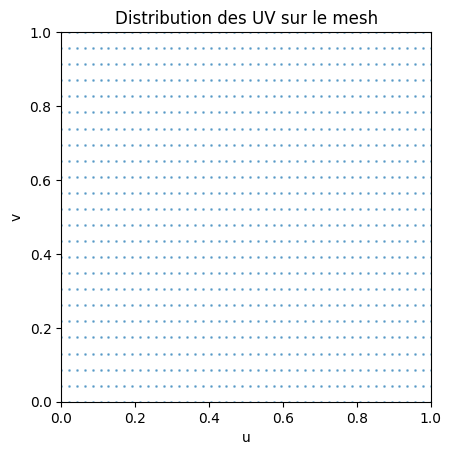

In [202]:
# Vérification des UV
assert uv_coords.shape[0] == mesh_pv.n_points, "UV count ≠ vertex count"
u_vals, v_vals = uv_coords[:, 0], uv_coords[:, 1]
print(f"u: [{u_vals.min():.4f}, {u_vals.max():.4f}]")
print(f"v: [{v_vals.min():.4f}, {v_vals.max():.4f}]")
plt.figure()
plt.scatter(u_vals, v_vals, s=1, alpha=0.5)
plt.xlim(0, 1); plt.ylim(0, 1)
plt.xlabel("u"); plt.ylabel("v")
plt.title("Distribution des UV sur le mesh")
plt.gca().set_aspect(1)
plt.show()

## 4️⃣ Visualisation avec Open3D

Le maillage texturé est exporté vers Open3D pour une visualisation interactive 3D (rotation, zoom). Les vertices, triangles et coordonnées UV sont construits à partir des données existantes.

In [203]:
import open3d as o3d

# --- Construction du maillage à partir de la grille (x2, y2, z2) ---
n, m = x2.shape
# On empile les coordonnées x, y, z de la grille (aplaties en 1D) pour former la liste des sommets du maillage.
# Chaque sommet est défini par (x, y, z).
vertices = np.column_stack([x2.ravel(), y2.ravel(), z2.ravel()])
print(vertices.shape)
# --- Triangles : 2 par quad (i,j) → (i+1,j+1) ---
triangles = []
for i in range(n - 1):
    for j in range(m - 1):
        v0, v1 = i * m + j, i * m + j + 1
        v2, v3 = (i + 1) * m + j + 1, (i + 1) * m + j
        triangles.append([v0, v1, v2])
        triangles.append([v0, v2, v3])
triangles = np.array(triangles)

# --- Coordonnées UV par triangle (3 paires u,v par triangle) ---
triangle_uvs = []
for i in range(n - 1):
    for j in range(m - 1):
        u, v = u_tex[i, j], v_tex[i, j]
        u *= 1.1
        v *= 1.1
        u1, v1 = u_tex[i, j + 1], v_tex[i, j + 1]
        u2, v2 = u_tex[i + 1, j + 1], v_tex[i + 1, j + 1]
        u3, v3 = u_tex[i + 1, j], v_tex[i + 1, j]
        triangle_uvs.extend([[u, v], [u1, v1], [u2, v2]])
        triangle_uvs.extend([[u, v], [u2, v2], [u3, v3]])
triangle_uvs = np.array(triangle_uvs, dtype=np.float64)



(1152, 3)


In [204]:
# --- Création du maillage et application de la texture ---
mesh = o3d.geometry.TriangleMesh()
mesh.vertices = o3d.utility.Vector3dVector(vertices)
mesh.triangles = o3d.utility.Vector3iVector(triangles)
mesh.triangle_uvs = o3d.utility.Vector2dVector(triangle_uvs)
mesh.textures = [o3d.geometry.Image(img_array)]


In [210]:
import scipy.io
import numpy as np

# Charger le fichier .mat qui contient 'xyzPoints'
mat = scipy.io.loadmat(r"C:\Users\mvm\open3d_vision\data\xyzPoints.mat")

# Supposons que 'xyzPoints' est dans le .mat (ajuste le nom de la clé si besoin)
xyzPoints = mat['xyzPoints']

# Pas besoin de 'pointCloud' de MATLAB, on utilise l'array directement avec matplotlib ou numpy
ptCloud = xyzPoints  # ptCloud sera un tableau numpy de forme (N,3)


In [ ]:
for array in ptCloud:
    print(array)


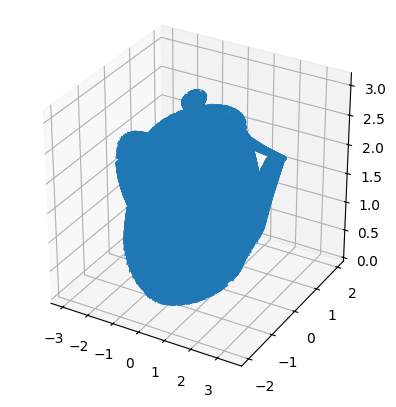

In [218]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

# ptCloud doit être (N, 3). Pour plot_surface il faut 2D grid, donc reshape si c'est possible.
# On suppose que ptCloud forme une grille (comme image ou mesh).
# Adapter n_rows, n_cols en fonction de ptCloud/xyzPoints réelles, ici pour exemple (100, 100).
n_rows, n_cols = ptCloud.shape[0], 1
if ptCloud.ndim == 3:
    # ptCloud est déjà un (H, W, 3)
    X = ptCloud[...,0]
    Y = ptCloud[...,1]
    Z = ptCloud[...,2]
elif ptCloud.ndim == 2:
    # Essayons de deviner s'il y a une grille possible
    N = ptCloud.shape[0]
    try:
        guessed_dim = int(np.sqrt(N))
        if guessed_dim * guessed_dim == N:
            X = ptCloud[:,0].reshape((guessed_dim, guessed_dim))
            Y = ptCloud[:,1].reshape((guessed_dim, guessed_dim))
            Z = ptCloud[:,2].reshape((guessed_dim, guessed_dim))
        else:
            raise ValueError("ptCloud n'est pas une grille carrée.")
    except Exception as e:
        print("Impossible de redimensionner ptCloud pour plot_surface:", e)
        # Fallback simple : scatter3D au lieu de plot_surface
        ax.scatter(ptCloud[:,0], ptCloud[:,1], ptCloud[:,2], s=1)
        ax.set_box_aspect([1, 1, 1])
        plt.show()
        # On sort ici, car plot_surface ne marchera pas
        import sys; sys.exit()

    # Tracé surface si reshape a réussi :
    ax.plot_surface(X, Y, Z, shade=False)
    ax.set_box_aspect([1, 1, 1])
    plt.show()

In [220]:
import pyvista as pv

# Activer l'affichage Jupyter (trame = rendu dans la cellule)
pv.set_jupyter_backend('trame')

# Gestion du nuage de points ptCloud pour affichage 3D avec PyVista
# ptCloud peut être (N, 3) ou (n, m, 3) si c'est une grille régulière

if ptCloud.ndim == 3 and ptCloud.shape[2] == 3:
    # Si ptCloud est une grille régulière, on peut en faire une surface
    n, m, _ = ptCloud.shape
    verts = ptCloud.reshape(-1, 3)
    # Création des faces (triangles) pour une surface régulière
    faces = []
    for i in range(n-1):
        for j in range(m-1):
            v0 = i*m + j
            v1 = i*m + (j+1)
            v2 = (i+1)*m + (j+1)
            v3 = (i+1)*m + j
            # Deux triangles par "cellule"
            faces.extend([[3, v0, v1, v2], [3, v0, v2, v3]])
    faces = np.hstack(faces).astype(np.int32)
    mesh_pv = pv.PolyData(verts, faces)
    # Optionnel: Ajout d'UV si u_tex/v_tex disponibles
    if "u_tex" in locals() and "v_tex" in locals():
        uv_coords = np.column_stack([u_tex.ravel(), 1.0 - v_tex.ravel()]).astype(np.float32)
        mesh_pv.active_texture_coordinates = uv_coords
    # Optionnel: texture image si présente
    if "img_array" in locals():
        tex = pv.numpy_to_texture(img_array)
        tex.wrap = pv.Texture.WrapType.CLAMP_TO_EDGE
    else:
        tex = None

    # Normales
    mesh_pv.compute_normals(inplace=True)
    reverse_normals = False
    if reverse_normals:
        mesh_pv["Normals"] = -mesh_pv["Normals"]

    # Affichage
    plotter = pv.Plotter(notebook=True)
    plotter.add_mesh(mesh_pv, texture=tex if 'tex' in locals() else None)
    plotter.add_mesh(mesh_pv.glyph(orient='Normals', scale=False, factor=-0.1), color='r', line_width=2, label='Normales')
    plotter.show()
else:
    # ptCloud est un nuage de points quelconque (N, 3)
    cloud = pv.PolyData(ptCloud)
    plotter = pv.Plotter(notebook=True)
    plotter.add_points(cloud, render_points_as_spheres=True, point_size=3)
    plotter.show()


Widget(value='<iframe src="http://localhost:62584/index.html?ui=P_0x1ea9c6aef60_31&reconnect=auto" class="pyvi…

In [222]:
import open3d

In [226]:
a = open3d.utility.Vector3dVector(ptCloud)
t = open3d.geometry.PointCloud(a)

In [230]:
# --- Option 1 : Poisson (recommandé pour pcd_glpn) - rapide et surface fermée ---
def mesh_poisson(pcd, depth=8, density_quantile=0.03):
    """Reconstruction Poisson : surface lisse et fermée, ~20x plus rapide que ball pivoting."""
    if not pcd.has_normals():
        pcd.estimate_normals(search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=0.05, max_nn=30))
    mesh, densities = o3d.geometry.TriangleMesh.create_from_point_cloud_poisson(pcd, depth=depth)
    densities = np.asarray(densities)
    mesh = mesh.select_by_index(np.where(densities > np.quantile(densities, density_quantile))[0])
    mesh.remove_degenerate_triangles()
    mesh.remove_duplicated_triangles()
    mesh.compute_vertex_normals()
    return mesh

rec_mesh = mesh_poisson(t, depth=8, density_quantile=0.1)
print("Poisson:", rec_mesh)
o3d.visualization.draw_geometries([t, rec_mesh], window_name="Poisson (recommandé)")

# --- Option 2 : Ball Pivoting optimisé (si requis pour comparaison) ---
# Sous-échantillonnage : gain ~10-50x en temps (BPA est O(n²))
VOXEL_SIZE = 0.01  # adapté à l'échelle pcd_glpn (depth en m, fx≈1000)
pcd_bp = t.voxel_down_sample(VOXEL_SIZE)
pcd_bp.estimate_normals(search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=0.05, max_nn=30))
pcd_bp.orient_normals_towards_camera_location(
    np.asarray(pcd_bp.points).mean(axis=0) + np.array([0, 0, 1.0])
)
# Rayons dérivés de l'espacement : 1.5x et 3x voxel_size (moins de rayons = plus rapide)

Poisson: TriangleMesh with 17892 points and 35313 triangles.
